In [1]:
import os
import pandas as pd
import json
from pathlib import Path
import re
import ast

target_folder = Path("./new_output")

results = []
spaces = dict()
total_trials = 0
total_experiments = 0

for inner_folder in os.listdir(target_folder):
    experiment_name = inner_folder
    try:
        trials_path = os.path.join(target_folder, inner_folder, "optuna_trials.csv")
        trials_df = pd.read_csv(trials_path)
        trials_df = trials_df.drop(["datetime_start", "datetime_complete"], axis=1, errors="ignore")
        total_trials += len(trials_df)
        total_experiments += 1

        raw_columns_count = len(trials_df.columns)
        trials_df["experiment_name"] = experiment_name

        details_path = os.path.join(target_folder, inner_folder, "experiment_details.json")
        with open(details_path, "r") as f:
            details = json.load(f)

        model_name = details.get("model_info", {}).get("name", None)
        search_space_path = os.path.join(target_folder, inner_folder, "merged_trial_distributions.txt")
        with open(search_space_path, "r") as f:
            _search_space_string = f.read()
            _search_space_string = _search_space_string.replace("\n", "")
            # fix format to make it json-like
            _search_space_string = re.sub("  +", "", _search_space_string)
            _search_space_string = re.sub("''+", "", _search_space_string)
            _search_space_string = re.sub("\"\"+", "", _search_space_string)
            search_space = ast.literal_eval(_search_space_string)
        # we expect each trial used the same distribution with no branching
        for key, value in search_space.items():
            assert len(value) == 1, f"Expected only one distribution for {key}, but got {len(value)}"
        spaces[model_name] = {key: value[0] for key, value in search_space.items()}

        for key in ["dataset_names", "smoothing_clip_upper_bound_type", "calculate_thresholds"]:
            if key in details:
                trials_df[key] = str(details[key])
            else:
                trials_df[key] = None
        trials_df["model"] = details.get("model_info", {}).get("name", None)

        new_columns_count = len(trials_df.columns)
        added_columns_count = new_columns_count - raw_columns_count

        # make added columns the first columns
        cols = trials_df.columns.tolist()
        cols = cols[-added_columns_count:] + cols[:-added_columns_count]
        trials_df = trials_df[cols]
        results.append(trials_df)
    except Exception as e:
        print(f"Error processing {experiment_name}: {e}")
print()
print(f"Total experiments: {total_experiments}")
print(f"Total trials: {total_trials}")

all_trials_df = pd.concat(results, ignore_index=True)
all_trials_df.columns = [col.replace("user_attrs", "u") for col in all_trials_df.columns]
all_trials_df


Error processing adaboostregressor_lobster_zoo_ca117773ab: [Errno 2] No such file or directory: 'new_output\\adaboostregressor_lobster_zoo_ca117773ab\\optuna_trials.csv'
Error processing mlpregressor_lobster_trick_zoo_d96cff325e: [Errno 2] No such file or directory: 'new_output\\mlpregressor_lobster_trick_zoo_d96cff325e\\optuna_trials.csv'
Error processing optuna_journal: [Errno 2] No such file or directory: 'new_output\\optuna_journal\\optuna_trials.csv'

Total experiments: 158
Total trials: 28560


,experiment_name,dataset_names,smoothing_clip_upper_bound_type,calculate_thresholds,model,number,value,duration,params_model__learning_rate,params_model__loss,...,params_model__p,params_model__weights,params_model__activation,params_model__alpha,params_model__early_stopping,params_model__learning_rate_init,params_model__max_iter,params_model__copy_X,params_model__fit_intercept,params_model__positive
0,adaboostregressor_lobster_trick_25a3c65d56,"['lobster', 'trick']",const160,True,AdaBoostRegressor,0,0.794884,0 days 00:00:22.086634,0.127966,square,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,adaboostregressor_lobster_trick_25a3c65d56,"['lobster', 'trick']",const160,True,AdaBoostRegressor,1,0.795152,0 days 00:00:29.082299,0.081548,square,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,adaboostregressor_lobster_trick_25a3c65d56,"['lobster', 'trick']",const160,True,AdaBoostRegressor,2,0.801230,0 days 00:00:31.366513,0.074365,exponential,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,adaboostregressor_lobster_trick_25a3c65d56,"['lobster', 'trick']",const160,True,AdaBoostRegressor,3,0.797559,0 days 00:00:09.241212,0.193078,linear,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,adaboostregressor_lobster_trick_25a3c65d56,"['lobster', 'trick']",const160,True,AdaBoostRegressor,4,0.789028,0 days 00:00:34.538712,0.187031,square,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28555,ridge_trick_zoo_c64c1a8336,"['trick', 'zoo']",FROM_FIT_FALLBACK_TO_UNSTRATIFIED,False,Ridge,295,0.789346,0 days 00:00:10.174638,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,False,False
28556,ridge_trick_zoo_c64c1a8336,"['trick', 'zoo']",FROM_FIT_FALLBACK_TO_UNSTRATIFIED,False,Ridge,296,0.789346,0 days 00:00:10.019828,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,False,False
28557,ridge_trick_zoo_c64c1a8336,"['trick', 'zoo']",FROM_FIT_FALLBACK_TO_UNSTRATIFIED,False,Ridge,297,0.789346,0 days 00:00:07.736372,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,False,False
28558,ridge_trick_zoo_c64c1a8336,"['trick', 'zoo']",FROM_FIT_FALLBACK_TO_UNSTRATIFIED,False,Ridge,298,0.789346,0 days 00:00:07.267880,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,False,False


In [2]:
final_cols = []
for i, col in enumerate(all_trials_df.columns):
    if i < added_columns_count + 2:
        final_cols.append(col)
    elif col.startswith("params_"):
        final_cols.append(col)
    elif col.startswith("u_"):
        final_cols.append(col)

# move params to the end
params_cols = [col for col in all_trials_df.columns if col.startswith("params_")]
final_cols = [col for col in final_cols if not col.startswith("params_")]

final_cols += params_cols

# drop per fold cols
final_cols = [col for col in final_cols if not (col[:-1].endswith("fold_"))]

# drop redundand overfit columns
final_cols = [col for col in final_cols if not ("overfit" in col)]


# for elem in final_cols:
#     print(elem)

results_df = all_trials_df[final_cols]

# filter for full dataset experiments
results_df = results_df[results_df["dataset_names"]=="['lobster', 'trick', 'zoo']"]
results_df = results_df[results_df["model"].isin(["GradientBoostingRegressor", "MLPRegressor", "Ridge"])]
# results_df = results_df.sort_values("value", ascending=False)

# shorten mean absolute error to mae
results_df.columns = [col.replace("mean_absolute_error", "mae") for col in results_df.columns]

results_df

,experiment_name,dataset_names,smoothing_clip_upper_bound_type,calculate_thresholds,model,number,value,u_total_cls_train_size_mean,u_total_cls_train_size_std,u_total_cls_val_size_mean,...,params_model__p,params_model__weights,params_model__activation,params_model__alpha,params_model__early_stopping,params_model__learning_rate_init,params_model__max_iter,params_model__copy_X,params_model__fit_intercept,params_model__positive
5490,gradientboostingregressor_lobster_trick_zoo_15...,"['lobster', 'trick', 'zoo']",FROM_FIT_UNSTRATIFIED,False,GradientBoostingRegressor,0,0.846164,950.4,4.615192,237.6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5491,gradientboostingregressor_lobster_trick_zoo_15...,"['lobster', 'trick', 'zoo']",FROM_FIT_UNSTRATIFIED,False,GradientBoostingRegressor,1,0.839900,950.4,4.615192,237.6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5492,gradientboostingregressor_lobster_trick_zoo_15...,"['lobster', 'trick', 'zoo']",FROM_FIT_UNSTRATIFIED,False,GradientBoostingRegressor,2,0.844352,950.4,4.615192,237.6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5493,gradientboostingregressor_lobster_trick_zoo_15...,"['lobster', 'trick', 'zoo']",FROM_FIT_UNSTRATIFIED,False,GradientBoostingRegressor,3,0.836752,950.4,4.615192,237.6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5494,gradientboostingregressor_lobster_trick_zoo_15...,"['lobster', 'trick', 'zoo']",FROM_FIT_UNSTRATIFIED,False,GradientBoostingRegressor,4,0.842788,950.4,4.615192,237.6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23755,ridge_lobster_trick_zoo_c8fcd1d5ec,"['lobster', 'trick', 'zoo']",FROM_FIT_UNSTRATIFIED,True,Ridge,295,0.779293,950.4,4.615192,237.6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,True,False
23756,ridge_lobster_trick_zoo_c8fcd1d5ec,"['lobster', 'trick', 'zoo']",FROM_FIT_UNSTRATIFIED,True,Ridge,296,0.779293,950.4,4.615192,237.6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,True,False
23757,ridge_lobster_trick_zoo_c8fcd1d5ec,"['lobster', 'trick', 'zoo']",FROM_FIT_UNSTRATIFIED,True,Ridge,297,0.779293,950.4,4.615192,237.6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,True,False
23758,ridge_lobster_trick_zoo_c8fcd1d5ec,"['lobster', 'trick', 'zoo']",FROM_FIT_UNSTRATIFIED,True,Ridge,298,0.779293,950.4,4.615192,237.6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,True,False


calculate_thresholds=True mean std score: 0.8104  0.0897
calculate_thresholds=False mean std score: 0.8015  0.0837


C:\Users\wndenis\AppData\Local\Temp\ipykernel_43180\1499183427.py:18: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(range(len(sub_df)), sub_df["value"].values, label=f"{_col_name}={val}", marker='o', c=cmap(code / len(_vals)), cmap='viridis')
C:\Users\wndenis\AppData\Local\Temp\ipykernel_43180\1499183427.py:18: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(range(len(sub_df)), sub_df["value"].values, label=f"{_col_name}={val}", marker='o', c=cmap(code / len(_vals)), cmap='viridis')


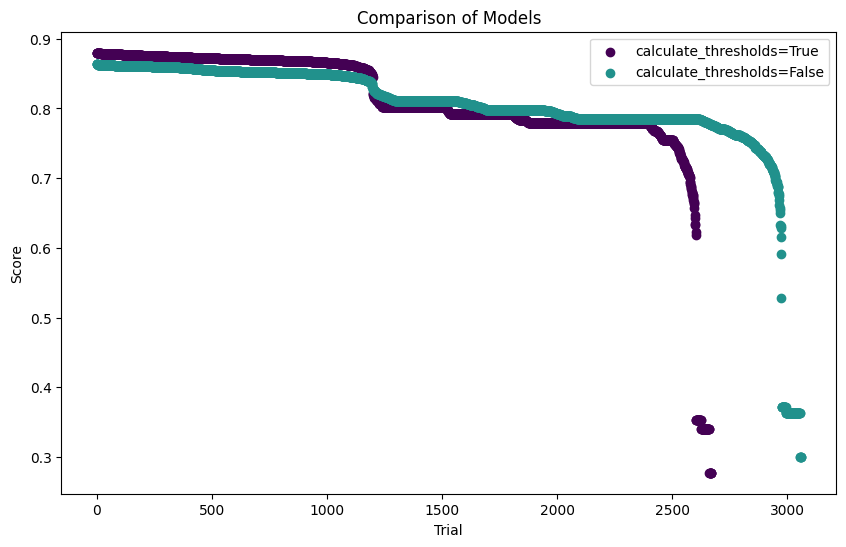

In [3]:
# parameter contribution to performance
import matplotlib.pyplot as plt
# temp = results_df[results_df["model"]=="MLPRegressor"].sort_values("value", ascending=False)
temp = results_df.sort_values("value", ascending=False)

_col_name = "calculate_thresholds"

plt.figure(figsize=(10, 6))

_vals = temp[_col_name].unique()
codes = dict(zip(_vals, range(len(_vals))))
cmap = plt.cm.viridis

for val in _vals:
    sub_df = temp[temp[_col_name] == val]
    code = codes[val]
    print(f"{_col_name}={val} mean std score: {sub_df['value'].mean():.4f}  {sub_df['value'].std():.4f}")
    plt.scatter(range(len(sub_df)), sub_df["value"].values, label=f"{_col_name}={val}", marker='o', c=cmap(code / len(_vals)), cmap='viridis')

plt.xlabel("Trial")
plt.ylabel("Score")
plt.title("Comparison of Models")
plt.legend()
plt.show()


In [4]:
# find top in each model type by target metric

top_df = pd.DataFrame()
for model_name in results_df["model"].unique():
    print(f"Model: {model_name}")
    group = results_df[results_df["model"] == model_name]
    top_model = group.sort_values("value", ascending=False).head(1)
    top_df = pd.concat([top_df, top_model], ignore_index=True)
top_df = top_df.sort_values("value", ascending=False)
display(top_df)


Model: GradientBoostingRegressor
Model: MLPRegressor
Model: Ridge


,experiment_name,dataset_names,smoothing_clip_upper_bound_type,calculate_thresholds,model,number,value,u_total_cls_train_size_mean,u_total_cls_train_size_std,u_total_cls_val_size_mean,...,params_model__p,params_model__weights,params_model__activation,params_model__alpha,params_model__early_stopping,params_model__learning_rate_init,params_model__max_iter,params_model__copy_X,params_model__fit_intercept,params_model__positive
0,gradientboostingregressor_lobster_trick_zoo_d6...,"['lobster', 'trick', 'zoo']",const160,True,GradientBoostingRegressor,281,0.879918,950.4,4.615192,237.6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,mlpregressor_lobster_trick_zoo_35b2335b0b,"['lobster', 'trick', 'zoo']",const160,False,MLPRegressor,310,0.830643,950.4,4.615192,237.6,...,NaN,NaN,tanh,0.004561,True,0.001548,1308.0,NaN,NaN,NaN
2,ridge_lobster_trick_zoo_2021637a40,"['lobster', 'trick', 'zoo']",FROM_FIT_FALLBACK_TO_CONST_160,False,Ridge,201,0.810884,950.4,4.615192,237.6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,False,False


In [5]:
from math import isnan

def meanstd(row: dict, key: str):
    mean = row.get(f"{key}_mean")
    std = row.get(f"{key}_std")
    return f"{mean:.4f} ± {std:.4f}"

last_df = pd.DataFrame()
last_hp_df = pd.DataFrame()

for model_name in top_df["model"].unique():
    row_df = top_df[top_df["model"] == model_name].iloc[0]
    row = row_df.to_dict()
    print(f"Model: {model_name}")
    
    final_df_record = {
        "experiment_name": row.get("experiment_name"),
        "Model": row.get("model"),
        "Smoothing clip upper bound type": row.get("smoothing_clip_upper_bound_type"),
        "Calculate thresholds": row.get("calculate_thresholds"),
        "R2 ↑": meanstd(row, "u_total_r2_score"),
        "R2 train ↑": meanstd(row, "u_total_r2_score_train"),
        "MAE ↓": meanstd(row, "u_total_mae"),
        "F1 ↑": meanstd(row, "u_total_f1_score"),
        "RocAuc ↑": meanstd(row, "u_total_roc_auc_score"),
        "Train size": meanstd(row, "u_total_train_size"),
        "Val size": meanstd(row, "u_total_val_size")
        }
    last_df = pd.concat([last_df, pd.DataFrame([final_df_record])], ignore_index=True)

    print("Search space:")
    for k, v in sorted(spaces[model_name].items(), key=lambda x: x[0]):
        print(f"  {k}: {v}")

    hyperparams = dict()
    hyperparams_row = {k: v for k, v in sorted(row.items(), key=lambda x: x[0]) if k.startswith("params_")}
    for k, v in hyperparams_row.items():
        if v is None:
            raise Exception(f"Unexpected None value for {k}")
        if isinstance(v, float) and isnan(v):
            continue
        hyperparams[k[7:]] = v  # cut params_ prefix
    # we can not distinguish None and NaN, so we assume that if a parameter is missing, it could be None
    hyperparams = {k: hyperparams.get(k, "None") for k in spaces[model_name].keys()}
    
    assert len(hyperparams) == len(spaces[model_name]), f"Expected {len(spaces[model_name])} hyperparameters, but got {len(hyperparams)}"
    hp_df = pd.DataFrame(columns=["Model", "Param", "Space", "Value"])
    hp_df["Param"] = hyperparams.keys()
    hp_df["Model"] = model_name
    hp_df["Space"] = hp_df["Param"].apply(lambda x: spaces[model_name][x])
    hp_df["Value"] = hyperparams.values()
    hp_df["Param"] = hp_df["Param"].str.replace("model__", "")
    last_hp_df = pd.concat([last_hp_df, hp_df], ignore_index=True)
    display(hp_df)
    print()

last_df


Model: GradientBoostingRegressor
Search space:
  model__learning_rate: FloatDistribution(high=0.1, log=False, low=0.025, step=None)
  model__max_depth: IntDistribution(high=6, log=False, low=3, step=1)
  model__max_features: CategoricalDistribution(choices=('sqrt', None))
  model__min_samples_leaf: IntDistribution(high=2, log=False, low=1, step=1)
  model__min_samples_split: IntDistribution(high=5, log=False, low=2, step=1)
  model__n_estimators: IntDistribution(high=1200, log=False, low=300, step=1)
  model__subsample: FloatDistribution(high=1.0, log=False, low=0.8, step=None)


,Model,Param,Space,Value
0,GradientBoostingRegressor,learning_rate,"FloatDistribution(high=0.1, log=False, low=0.0...",0.03463
1,GradientBoostingRegressor,max_depth,"IntDistribution(high=6, log=False, low=3, step=1)",6.0
2,GradientBoostingRegressor,max_features,"CategoricalDistribution(choices=('sqrt', None))",None
3,GradientBoostingRegressor,min_samples_leaf,"IntDistribution(high=2, log=False, low=1, step=1)",1.0
4,GradientBoostingRegressor,min_samples_split,"IntDistribution(high=5, log=False, low=2, step=1)",5.0
5,GradientBoostingRegressor,n_estimators,"IntDistribution(high=1200, log=False, low=300,...",618.0
6,GradientBoostingRegressor,subsample,"FloatDistribution(high=1.0, log=False, low=0.8...",0.805714



Model: MLPRegressor
Search space:
  model__activation: CategoricalDistribution(choices=('relu', 'tanh'))
  model__alpha: FloatDistribution(high=0.1, log=False, low=0.0001, step=None)
  model__early_stopping: CategoricalDistribution(choices=(True, False))
  model__learning_rate_init: FloatDistribution(high=0.01, log=False, low=0.001, step=None)
  model__max_iter: IntDistribution(high=1500, log=False, low=500, step=1)


,Model,Param,Space,Value
0,MLPRegressor,activation,"CategoricalDistribution(choices=('relu', 'tanh'))",tanh
1,MLPRegressor,alpha,"FloatDistribution(high=0.1, log=False, low=0.0...",0.004561
2,MLPRegressor,early_stopping,"CategoricalDistribution(choices=(True, False))",True
3,MLPRegressor,learning_rate_init,"FloatDistribution(high=0.01, log=False, low=0....",0.001548
4,MLPRegressor,max_iter,"IntDistribution(high=1500, log=False, low=500,...",1308.0



Model: Ridge
Search space:
  model__copy_X: CategoricalDistribution(choices=(True, False))
  model__fit_intercept: CategoricalDistribution(choices=(True, False))
  model__positive: CategoricalDistribution(choices=(False, True))


,Model,Param,Space,Value
0,Ridge,copy_X,"CategoricalDistribution(choices=(True, False))",True
1,Ridge,fit_intercept,"CategoricalDistribution(choices=(True, False))",False
2,Ridge,positive,"CategoricalDistribution(choices=(False, True))",False


,experiment_name,Model,Smoothing clip upper bound type,Calculate thresholds,R2 ↑,R2 train ↑,MAE ↓,F1 ↑,RocAuc ↑,Train size,Val size
0,gradientboostingregressor_lobster_trick_zoo_d6...,GradientBoostingRegressor,const160,True,0.8799 ± 0.0193,0.9993 ± 0.0001,0.0407 ± 0.0022,0.8701 ± 0.0466,0.9054 ± 0.0383,950.4000 ± 4.6152,237.6000 ± 4.6152
1,mlpregressor_lobster_trick_zoo_35b2335b0b,MLPRegressor,const160,False,0.8306 ± 0.0356,0.8509 ± 0.0122,0.0571 ± 0.0081,0.8782 ± 0.0149,0.9115 ± 0.0175,950.4000 ± 4.6152,237.6000 ± 4.6152
2,ridge_lobster_trick_zoo_2021637a40,Ridge,FROM_FIT_FALLBACK_TO_CONST_160,False,0.8109 ± 0.0308,0.8272 ± 0.0085,0.0676 ± 0.0072,0.8445 ± 0.0233,0.9009 ± 0.0222,950.4000 ± 4.6152,237.6000 ± 4.6152


In [6]:
last_df.T

,0,1,2
experiment_name,gradientboostingregressor_lobster_trick_zoo_d6...,mlpregressor_lobster_trick_zoo_35b2335b0b,ridge_lobster_trick_zoo_2021637a40
Model,GradientBoostingRegressor,MLPRegressor,Ridge
Smoothing clip upper bound type,const160,const160,FROM_FIT_FALLBACK_TO_CONST_160
Calculate thresholds,True,False,False
R2 ↑,0.8799 ± 0.0193,0.8306 ± 0.0356,0.8109 ± 0.0308
R2 train ↑,0.9993 ± 0.0001,0.8509 ± 0.0122,0.8272 ± 0.0085
MAE ↓,0.0407 ± 0.0022,0.0571 ± 0.0081,0.0676 ± 0.0072
F1 ↑,0.8701 ± 0.0466,0.8782 ± 0.0149,0.8445 ± 0.0233
RocAuc ↑,0.9054 ± 0.0383,0.9115 ± 0.0175,0.9009 ± 0.0222
Train size,950.4000 ± 4.6152,950.4000 ± 4.6152,950.4000 ± 4.6152


In [7]:
last_hp_df

,Model,Param,Space,Value
0,GradientBoostingRegressor,learning_rate,"FloatDistribution(high=0.1, log=False, low=0.0...",0.03463
1,GradientBoostingRegressor,max_depth,"IntDistribution(high=6, log=False, low=3, step=1)",6.0
2,GradientBoostingRegressor,max_features,"CategoricalDistribution(choices=('sqrt', None))",None
3,GradientBoostingRegressor,min_samples_leaf,"IntDistribution(high=2, log=False, low=1, step=1)",1.0
4,GradientBoostingRegressor,min_samples_split,"IntDistribution(high=5, log=False, low=2, step=1)",5.0
5,GradientBoostingRegressor,n_estimators,"IntDistribution(high=1200, log=False, low=300,...",618.0
6,GradientBoostingRegressor,subsample,"FloatDistribution(high=1.0, log=False, low=0.8...",0.805714
7,MLPRegressor,activation,"CategoricalDistribution(choices=('relu', 'tanh'))",tanh
8,MLPRegressor,alpha,"FloatDistribution(high=0.1, log=False, low=0.0...",0.004561
9,MLPRegressor,early_stopping,"CategoricalDistribution(choices=(True, False))",True


In [8]:
# # single run results
# import os
# import pandas as pd
# import json
# from pathlib import Path

# target_folder = Path("./new_output")

# results = []
# for inner_folder in os.listdir(target_folder):
#     experiment_name = inner_folder
#     try:
#         cls_report_path = os.path.join(target_folder, inner_folder, "evaluation_results.csv")
#         report = {"experiment_name": experiment_name}
#         report_series = pd.read_csv(cls_report_path).to_dict(orient="records")[0]
#         report.update(report_series)

#         report_series = pd.Series(report)

#         results.append(report_series)
#     except Exception as e:
#         print(f"Error processing {experiment_name}: {e}")

# results_df = pd.DataFrame(results)
# results_df
